# Analyse clinique descriptive et analyse de survie

Ce notebook analyse le jeu de données public SEER Breast Cancer Data
après sa préparation et son contrôle de qualité.

Les objectifs sont :

- examiner la cohorte disponible ;
- décrire les principales variables cliniques ;
- présenter la répartition des cas selon le stade ;
- estimer la survie observée avec la méthode de Kaplan-Meier.

Cette analyse est réalisée à des fins pédagogiques. Elle ne constitue
ni une prédiction individuelle ni une recommandation médicale.

In [1]:
# ============================================================
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from lifelines import KaplanMeierFitter

In [2]:
# ============================================================
# 2. LOCALISATION DU PROJET ET DES FICHIERS
# ============================================================

# Selon la manière dont VS Code ouvre le notebook,
# Path.cwd() peut désigner la racine du projet
# ou le dossier notebooks.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "oncology_registry_validated.csv"
)


FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)


# Crée automatiquement outputs/figures si nécessaire.
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("Racine du projet :", PROJECT_ROOT)
print("Fichier de données :", DATA_FILE)
print("Le fichier existe :", DATA_FILE.exists())


if not DATA_FILE.exists():
    raise FileNotFoundError(
        "Le fichier oncology_registry_validated.csv est absent. "
        "Exécutez d'abord python -m src.prepare_data, "
        "puis python -m src.validate_data."
    )


Racine du projet : c:\Users\dmmaz\GitHub\oncology-clinical-registry-analytics
Fichier de données : c:\Users\dmmaz\GitHub\oncology-clinical-registry-analytics\data\processed\oncology_registry_validated.csv
Le fichier existe : True


In [3]:
# ============================================================
# 3. CHARGEMENT DES DONNÉES VALIDÉES
# ============================================================

df = pd.read_csv(DATA_FILE)


print()
print("Dimensions du fichier :")
print(f"- Nombre de lignes : {df.shape[0]}")
print(f"- Nombre de colonnes : {df.shape[1]}")


Dimensions du fichier :
- Nombre de lignes : 4024
- Nombre de colonnes : 21


In [4]:
# ============================================================
# 4. VÉRIFICATION DES VARIABLES NÉCESSAIRES
# ============================================================

required_columns = [
    "case_id",
    "age",
    "overall_stage",
    "tumor_size",
    "regional_nodes_examined",
    "regional_nodes_positive",
    "survival_months",
    "vital_status",
    "event",
    "quality_status",
]


missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]


if missing_columns:
    raise ValueError(
        "Certaines variables nécessaires sont absentes : "
        f"{missing_columns}"
    )


print()
print("Toutes les variables nécessaires sont présentes.")


Toutes les variables nécessaires sont présentes.


In [5]:
# ============================================================
# 5. EXAMEN DU STATUT DE QUALITÉ
# ============================================================

quality_counts = (
    df["quality_status"]
    .value_counts(dropna=False)
)


print()
print("Répartition selon le statut de qualité :")
print(quality_counts.to_string())


Répartition selon le statut de qualité :
quality_status
valid           4022
needs_review       2


In [6]:
# ============================================================
# 6. CONSTRUCTION DE LA COHORTE ANALYTIQUE
# ============================================================

# Pour cette première analyse, seuls les dossiers classés
# comme techniquement valides sont retenus.
# Les autres dossiers ne sont pas supprimés du fichier source.
analysis_df = df.loc[
    df["quality_status"].eq("valid")
].copy()


print()
print(
    f"Cohorte analytique : {len(analysis_df)} dossiers "
    f"sur {len(df)} dossiers disponibles."
)


if analysis_df.empty:
    raise ValueError(
        "Aucun dossier n'est classé comme valide. "
        "Vérifiez le rapport de qualité avant de poursuivre."
    )


Cohorte analytique : 4022 dossiers sur 4024 dossiers disponibles.


In [7]:
# ============================================================
# 7. CONVERSION DES VARIABLES NUMÉRIQUES
# ============================================================

numeric_columns = [
    "age",
    "tumor_size",
    "regional_nodes_examined",
    "regional_nodes_positive",
    "survival_months",
    "event",
]


for column in numeric_columns:
    analysis_df[column] = pd.to_numeric(
        analysis_df[column],
        errors="coerce",
    )

In [8]:
# ============================================================
# 8. STATISTIQUES DESCRIPTIVES
# ============================================================

descriptive_columns = [
    "age",
    "tumor_size",
    "regional_nodes_examined",
    "regional_nodes_positive",
    "survival_months",
]


descriptive_statistics = (
    analysis_df[descriptive_columns]
    .describe()
    .transpose()
)


print()
print("Statistiques descriptives :")
print(descriptive_statistics.to_string())


Statistiques descriptives :
                          count       mean        std   min   25%   50%   75%    max
age                      4022.0  53.967678   8.963101  30.0  47.0  54.0  61.0   69.0
tumor_size               4022.0  30.480358  21.122809   1.0  16.0  25.0  38.0  140.0
regional_nodes_examined  4022.0  14.359771   8.100807   1.0   9.0  14.0  19.0   61.0
regional_nodes_positive  4022.0   4.159622   5.110116   1.0   1.0   2.0   5.0   46.0
survival_months          4022.0  71.305569  22.924589   1.0  56.0  73.0  90.0  107.0


In [9]:
# ============================================================
# 9. RÉPARTITION DES CAS SELON LE STADE
# ============================================================

stage_counts = (
    analysis_df["overall_stage"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("overall_stage")
    .reset_index(name="number_of_cases")
)


stage_counts["percentage"] = (
    stage_counts["number_of_cases"]
    / stage_counts["number_of_cases"].sum()
    * 100
).round(2)


print()
print("Répartition des cas selon le stade :")
print(stage_counts.to_string(index=False))


Répartition des cas selon le stade :
overall_stage  number_of_cases  percentage
          IIA             1303       32.40
          IIB             1130       28.10
         IIIA             1050       26.11
         IIIB               67        1.67
         IIIC              472       11.74


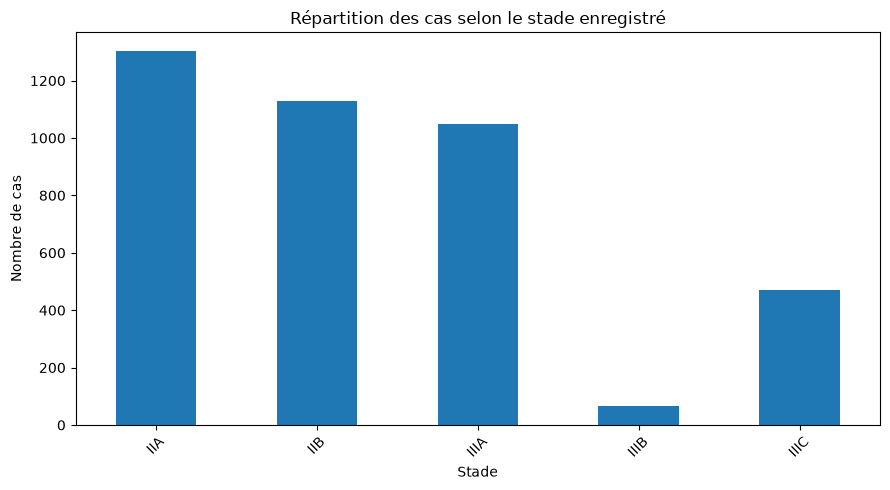

In [10]:
# ============================================================
# 10. GRAPHIQUE DE LA RÉPARTITION DES STADES
# ============================================================

stage_plot_data = (
    analysis_df["overall_stage"]
    .dropna()
    .value_counts()
    .sort_index()
)


figure_stage, axis_stage = plt.subplots(
    figsize=(9, 5)
)


stage_plot_data.plot(
    kind="bar",
    ax=axis_stage,
)


axis_stage.set_title(
    "Répartition des cas selon le stade enregistré"
)

axis_stage.set_xlabel("Stade")
axis_stage.set_ylabel("Nombre de cas")


plt.xticks(rotation=45)
plt.tight_layout()


figure_stage.savefig(
    FIGURES_DIR / "stage_distribution.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

In [11]:
# ============================================================
# 11. CRÉATION DE LA TABLE D'ANALYSE DE SURVIE
# ============================================================

# Cette instruction crée survival_df.
# Toutes les utilisations de survival_df viennent après elle.
survival_df = analysis_df.dropna(
    subset=[
        "survival_months",
        "event",
    ]
).copy()


survival_df["survival_months"] = pd.to_numeric(
    survival_df["survival_months"],
    errors="coerce",
)


survival_df["event"] = pd.to_numeric(
    survival_df["event"],
    errors="coerce",
)


survival_df = survival_df.dropna(
    subset=[
        "survival_months",
        "event",
    ]
).copy()


survival_df["event"] = (
    survival_df["event"]
    .astype(int)
)


invalid_event_values = set(
    survival_df["event"].unique()
).difference({0, 1})


if invalid_event_values:
    raise ValueError(
        "La variable event contient des valeurs autres que 0 et 1 : "
        f"{invalid_event_values}"
    )


if survival_df.empty:
    raise ValueError(
        "Aucune observation n'est disponible pour l'analyse de survie."
    )


print()
print(
    "Nombre de dossiers utilisables pour l'analyse de survie :",
    len(survival_df),
)


print(
    "Nombre de décès observés :",
    int(survival_df["event"].sum()),
)



Nombre de dossiers utilisables pour l'analyse de survie : 4022
Nombre de décès observés : 616


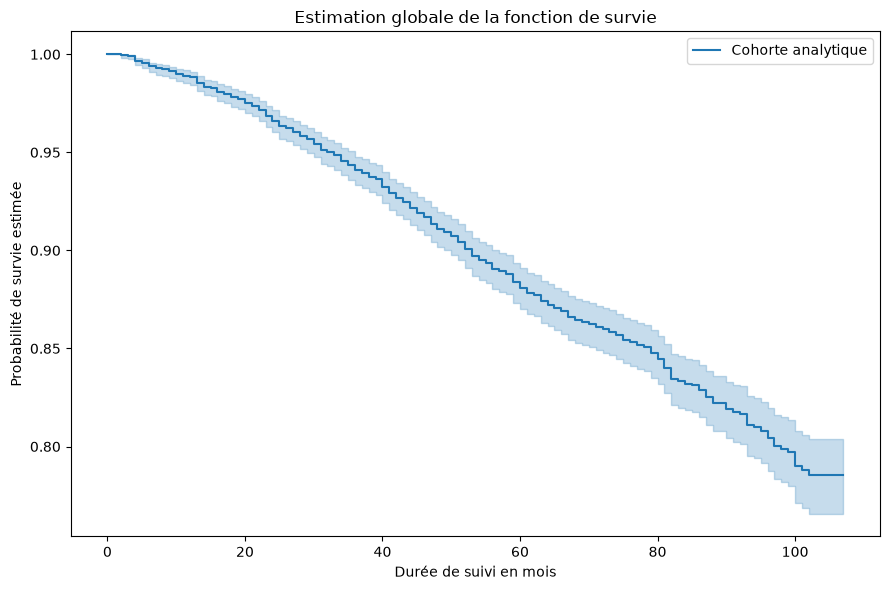


Médiane de survie estimée : inf


In [12]:
# ============================================================
# 12. KAPLAN-MEIER GLOBAL
# ============================================================

kmf_global = KaplanMeierFitter()


kmf_global.fit(
    durations=survival_df["survival_months"],
    event_observed=survival_df["event"],
    label="Cohorte analytique",
)


figure_global, axis_global = plt.subplots(
    figsize=(9, 6)
)


kmf_global.plot_survival_function(
    ax=axis_global,
)


axis_global.set_title(
    "Estimation globale de la fonction de survie"
)

axis_global.set_xlabel(
    "Durée de suivi en mois"
)

axis_global.set_ylabel(
    "Probabilité de survie estimée"
)


plt.tight_layout()


figure_global.savefig(
    FIGURES_DIR / "overall_survival.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()


median_survival = (
    kmf_global.median_survival_time_
)


print()
print(
    "Médiane de survie estimée :",
    median_survival,
)


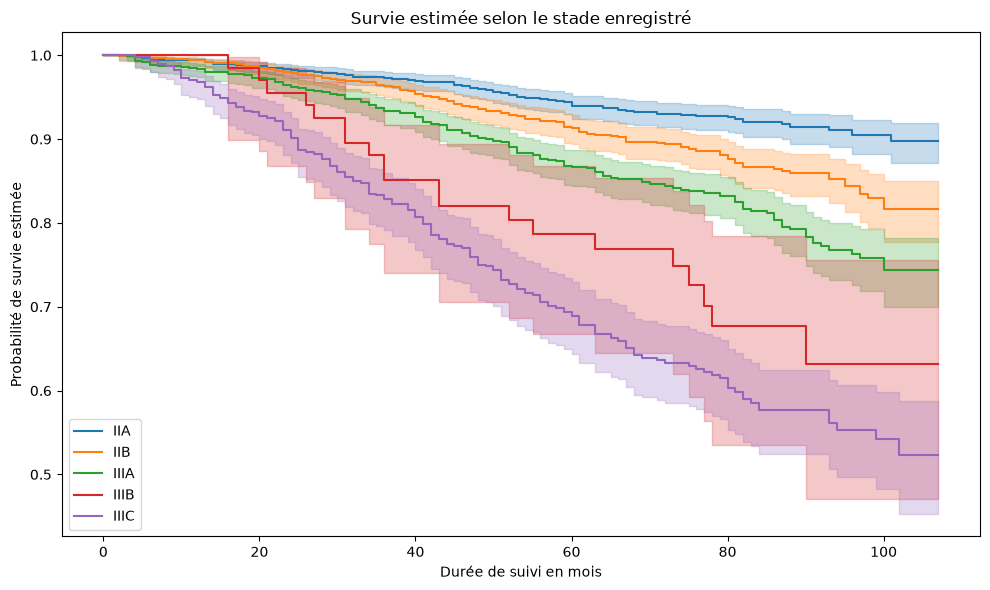

In [13]:
# ============================================================
# 13. KAPLAN-MEIER SELON LE STADE
# ============================================================

figure_stage_survival, axis_stage_survival = plt.subplots(
    figsize=(10, 6)
)


number_of_curves = 0


for stage, group in survival_df.dropna(
    subset=["overall_stage"]
).groupby("overall_stage"):

    # Les groupes trop petits ne sont pas représentés.
    if len(group) < 10:
        print(
            f"Stade {stage} non représenté : "
            f"seulement {len(group)} dossiers."
        )
        continue

    kmf_stage = KaplanMeierFitter()

    kmf_stage.fit(
        durations=group["survival_months"],
        event_observed=group["event"],
        label=str(stage),
    )

    kmf_stage.plot_survival_function(
        ax=axis_stage_survival,
    )

    number_of_curves += 1


if number_of_curves == 0:
    plt.close(figure_stage_survival)

    print(
        "Aucune courbe par stade n'a été produite, "
        "car les groupes disponibles sont trop petits."
    )

else:
    axis_stage_survival.set_title(
        "Survie estimée selon le stade enregistré"
    )

    axis_stage_survival.set_xlabel(
        "Durée de suivi en mois"
    )

    axis_stage_survival.set_ylabel(
        "Probabilité de survie estimée"
    )

    plt.tight_layout()

    figure_stage_survival.savefig(
        FIGURES_DIR / "survival_by_stage.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [14]:
# ============================================================
# 14. MESSAGE FINAL
# ============================================================

print()
print("Analyse clinique terminée avec succès.")
print("Graphiques enregistrés dans :", FIGURES_DIR)


Analyse clinique terminée avec succès.
Graphiques enregistrés dans : c:\Users\dmmaz\GitHub\oncology-clinical-registry-analytics\outputs\figures


## Interprétation

L'analyse présente la structure descriptive de la cohorte et
l'évolution de la survie observée pendant le suivi.

Les courbes de survie peuvent différer selon le stade enregistré.
Ces différences constituent des associations descriptives au sein
de ce jeu de données.

Elles ne démontrent pas qu'un stade produit, à lui seul, une
différence de survie. Les groupes peuvent également différer selon
l'âge, la taille tumorale, les atteintes ganglionnaires, les
caractéristiques biologiques et d'autres facteurs non pris en compte.

Cette analyse ne constitue ni une prédiction individuelle ni une
recommandation médicale.